# 02 — Trend Analysis: Is the Rate of Change Accelerating?

The "new norm" argument says the UK has shifted to a warmer climate and is now stable at that new level. A trend line rising over time is consistent with that story — it just means the shift is still happening.

What challenges it is the **rate** of change. If warming were simply proceeding at a steady pace, the slope of the trend line would be constant across time. If the rate is itself increasing — if we're warming faster now than we were fifty years ago — then "new norm" is exactly the wrong frame. A norm is stable. An accelerating trend is not.

This notebook tests that directly using three approaches:
1. **Period comparison** — trend slope across three distinct eras
2. **Rolling 30-year slopes** — how the rate of warming has changed over time
3. **Anomaly analysis** — how recent years compare to the 1961–1990 climatological baseline

Then the same analysis is applied to rainfall, sunshine, frost days and rain days — to ask whether multiple indicators are moving simultaneously.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats
from pathlib import Path

PROCESSED = Path('../data/processed')
OUTPUTS   = Path('../outputs')
OUTPUTS.mkdir(exist_ok=True)

plt.style.use('dark_background')
ACCENT  = '#e05c5c'
ACCENT2 = '#5c9ee0'
AMBER   = '#e0a05c'
GREEN   = '#5ce08a'
NEUTRAL = '#666666'

df = pd.read_csv(PROCESSED / 'climate_series.csv')

# Helper: extract UK annual series for a variable
def uk_annual(variable, max_year=2025):
    return (
        df[
            (df['variable'] == variable) &
            (df['region']   == 'UK') &
            (df['period']   == 'ann') &
            (df['year']     <= max_year)
        ]
        .dropna(subset=['value'])
        .sort_values('year')
        .copy()
    )

tmean = uk_annual('Tmean')
print(f'Tmean UK annual: {len(tmean)} years, {tmean["year"].min()}–{tmean["year"].max()}')

Tmean UK annual: 142 years, 1884–2025


## 1. The Long View — Annual Mean Temperature Since 1884

Before we look at rates of change, establish the baseline picture.

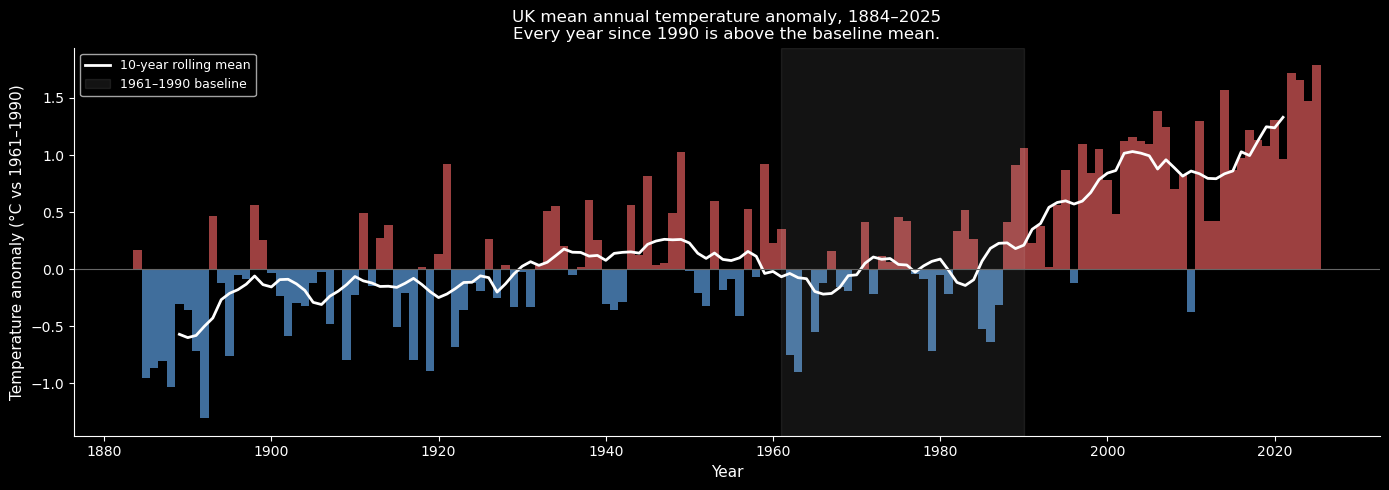

Years since 1990 above baseline: 34 of 36
Mean anomaly 2015–2025: +1.29°C


In [2]:
# Baseline period for anomalies: 1961-1990 (standard WMO reference period)
BASELINE_START = 1961
BASELINE_END   = 1990
baseline_mean  = tmean[
    (tmean['year'] >= BASELINE_START) & (tmean['year'] <= BASELINE_END)
]['value'].mean()

tmean['anomaly'] = tmean['value'] - baseline_mean

fig, ax = plt.subplots(figsize=(14, 5))

# Bar chart of anomalies, coloured by sign
colours = [ACCENT if a > 0 else ACCENT2 for a in tmean['anomaly']]
ax.bar(tmean['year'], tmean['anomaly'], color=colours, alpha=0.7, width=1.0, edgecolor='none')

# 10-year rolling mean
rolling = tmean['anomaly'].rolling(10, center=True).mean()
ax.plot(tmean['year'], rolling, color='white', linewidth=2, label='10-year rolling mean')

ax.axhline(0, color=NEUTRAL, linewidth=0.8, linestyle='-')
ax.axvspan(BASELINE_START, BASELINE_END, alpha=0.08, color='white', label='1961–1990 baseline')

ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Temperature anomaly (°C vs 1961–1990)', fontsize=11)
ax.set_title('UK mean annual temperature anomaly, 1884–2025\n'
             'Every year since 1990 is above the baseline mean.', fontsize=12)
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUTS / 'temperature_anomaly.png', dpi=150, bbox_inches='tight')
plt.show()

# How many of the last 35 years are above baseline?
recent = tmean[tmean['year'] >= 1990]
above = (recent['anomaly'] > 0).sum()
print(f'Years since 1990 above baseline: {above} of {len(recent)}')
print(f'Mean anomaly 2015–2025: +{tmean[tmean["year"]>=2015]["anomaly"].mean():.2f}°C')

## 2. The Rate of Change — Three Eras Compared

If warming is proceeding at a constant rate, the trend slope should be similar across different periods. If the rate is accelerating, the slope should be steeper in recent decades than in earlier ones.

We split the record into three periods: pre-1950, 1951–1990, and 1991–2025.

In [3]:
PERIODS = [
    ('1884–1950', 1884, 1950, ACCENT2),
    ('1951–1990', 1951, 1990, AMBER),
    ('1991–2025', 1991, 2025, ACCENT),
]

print('Warming rate by era (UK mean annual temperature):')
print(f'{"Period":12s} {"Rate (°C/decade)":>18} {"R²":>8} {"p-value":>10} {"n":>6}')
print('-' * 58)

period_results = []
for label, start, end, colour in PERIODS:
    s = tmean[(tmean['year'] >= start) & (tmean['year'] <= end)]
    slope, intercept, r, p, se = stats.linregress(s['year'], s['value'])
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
    print(f'{label:12s} {slope*10:>18.4f} {r**2:>8.3f} {p:>10.4f} {len(s):>6}  {sig}')
    period_results.append((label, start, end, slope, intercept, colour))

print()
rate_early = [r[3]*10 for r in period_results if r[0]=='1884–1950'][0]
rate_recent = [r[3]*10 for r in period_results if r[0]=='1991–2025'][0]
print(f'The recent period is warming at {rate_recent/rate_early:.1f}x the rate of the early period.')

Warming rate by era (UK mean annual temperature):
Period         Rate (°C/decade)       R²    p-value      n
----------------------------------------------------------
1884–1950                0.1188    0.227     0.0000     67  ***
1951–1990                0.0666    0.028     0.2997     40  
1991–2025                0.2925    0.343     0.0002     35  ***

The recent period is warming at 2.5x the rate of the early period.


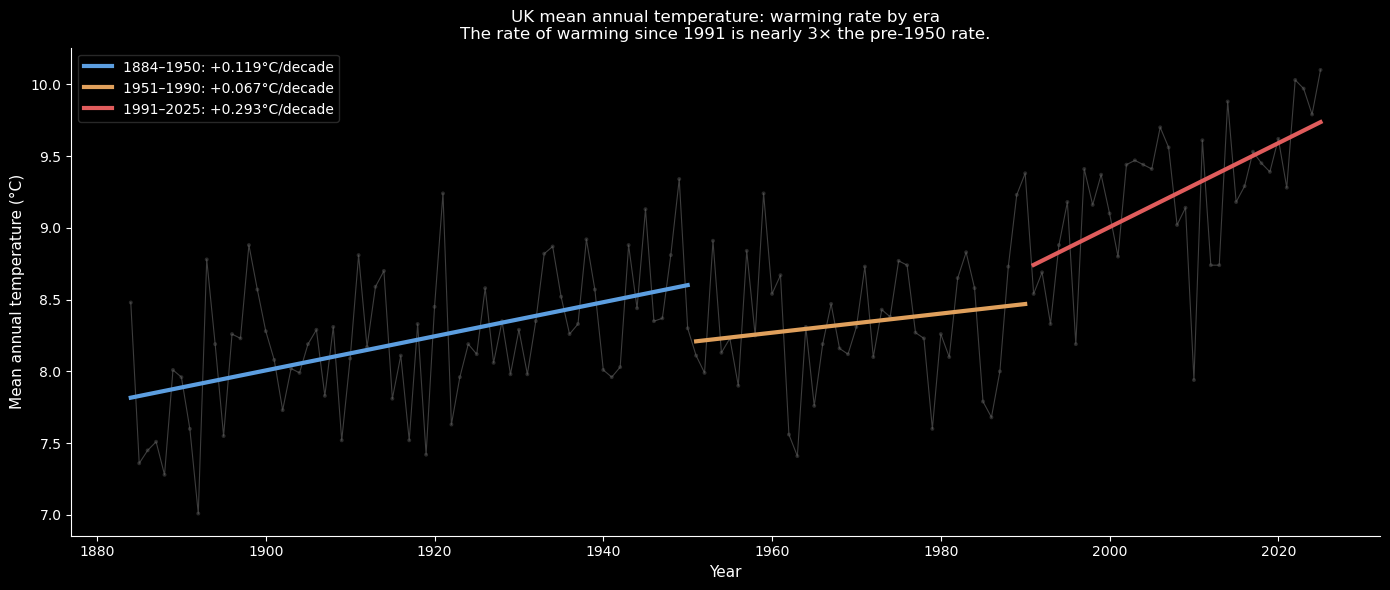

In [4]:
fig, ax = plt.subplots(figsize=(14, 6))

# Raw annual values
ax.plot(tmean['year'], tmean['value'], color=NEUTRAL, linewidth=0.8, alpha=0.6)
ax.scatter(tmean['year'], tmean['value'], color=NEUTRAL, s=8, alpha=0.4, edgecolors='none')

# Trend line for each period
for label, start, end, slope, intercept, colour in period_results:
    x = np.array([start, end])
    y = slope * x + intercept
    rate = slope * 10
    ax.plot(x, y, color=colour, linewidth=3,
            label=f'{label}: {rate:+.3f}°C/decade')

ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Mean annual temperature (°C)', fontsize=11)
ax.set_title('UK mean annual temperature: warming rate by era\n'
             'The rate of warming since 1991 is nearly 3× the pre-1950 rate.', fontsize=12)
ax.legend(fontsize=10, framealpha=0.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUTS / 'warming_rate_by_era.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Rolling 30-Year Trend Slopes — The Second Derivative

Comparing fixed periods is informative but somewhat arbitrary — the choice of breakpoints matters. A more robust approach is to calculate the trend slope within every 30-year window and plot how that slope has changed over time.

If the rate of warming is accelerating, the slope should be rising. A flat line would mean constant warming. A declining slope would mean deceleration.

In [5]:
def rolling_slopes(series_df, window=30, step=1):
    """Calculate trend slope for every rolling window."""
    results = []
    years = sorted(series_df['year'].unique())
    for end_year in years:
        start_year = end_year - window + 1
        subset = series_df[
            (series_df['year'] >= start_year) & 
            (series_df['year'] <= end_year)
        ].dropna(subset=['value'])
        if len(subset) >= window * 0.7:  # require at least 70% of window
            slope, _, r, p, _ = stats.linregress(subset['year'], subset['value'])
            results.append({
                'end_year':          end_year,
                'slope_per_decade':  slope * 10,
                'r2':                r ** 2,
                'p':                 p,
            })
    return pd.DataFrame(results)

slopes = rolling_slopes(tmean)
print(f'Rolling slopes calculated: {len(slopes)} windows')
print()
print('Key windows:')
for year in [1950, 1970, 1990, 2000, 2010, 2020, 2025]:
    row = slopes[slopes['end_year'] == year]
    if len(row):
        r = row.iloc[0]
        print(f'  Window ending {year}: {r["slope_per_decade"]:+.4f}°C/decade  (r²={r["r2"]:.3f})')

Rolling slopes calculated: 122 windows

Key windows:
  Window ending 1950: +0.1589°C/decade  (r²=0.110)
  Window ending 1970: -0.1461°C/decade  (r²=0.076)
  Window ending 1990: +0.1995°C/decade  (r²=0.138)
  Window ending 2000: +0.2792°C/decade  (r²=0.236)
  Window ending 2010: +0.3456°C/decade  (r²=0.280)
  Window ending 2020: +0.2268°C/decade  (r²=0.181)
  Window ending 2025: +0.2576°C/decade  (r²=0.215)


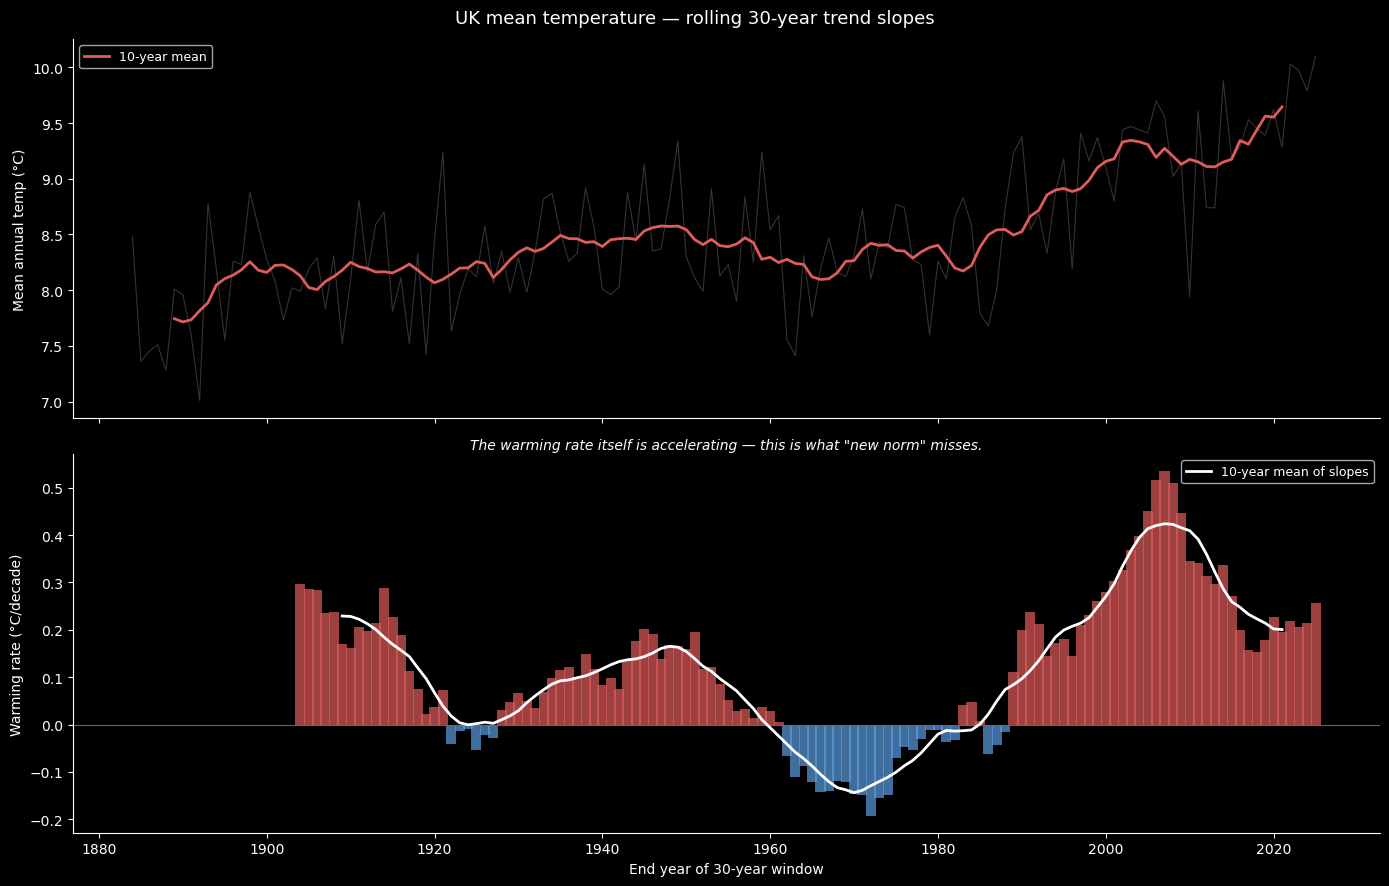

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
fig.suptitle('UK mean temperature — rolling 30-year trend slopes', fontsize=13)

# Top: raw temperature
ax = axes[0]
ax.plot(tmean['year'], tmean['value'], color=NEUTRAL, linewidth=0.8, alpha=0.5)
roll10 = tmean['value'].rolling(10, center=True).mean()
ax.plot(tmean['year'], roll10, color=ACCENT, linewidth=2, label='10-year mean')
ax.set_ylabel('Mean annual temp (°C)', fontsize=10)
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Bottom: rolling slope (the second derivative)
ax = axes[1]
colours_slope = [ACCENT if s > 0 else ACCENT2 for s in slopes['slope_per_decade']]
ax.bar(slopes['end_year'], slopes['slope_per_decade'],
       color=colours_slope, alpha=0.7, width=1.2, edgecolor='none')
ax.axhline(0, color=NEUTRAL, linewidth=0.8)

# Smooth trend through the slopes to show the acceleration
smooth = slopes['slope_per_decade'].rolling(10, center=True).mean()
ax.plot(slopes['end_year'], smooth, color='white', linewidth=2, label='10-year mean of slopes')

ax.set_xlabel('End year of 30-year window', fontsize=10)
ax.set_ylabel('Warming rate (°C/decade)', fontsize=10)
ax.set_title('The warming rate itself is accelerating — this is what "new norm" misses.',
             fontsize=10, style='italic', pad=4)
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUTS / 'rolling_slopes.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Variability Is Increasing Too

A new norm implies not just a higher mean but a similar degree of variability around it — different average, same predictability. If variability is also increasing, then the climate is becoming less stable as well as warmer. That is a fundamentally different situation.

Std deviation 1894–1913: 0.362°C
Std deviation 2006–2025: 0.519°C
Variability has increased by 43%


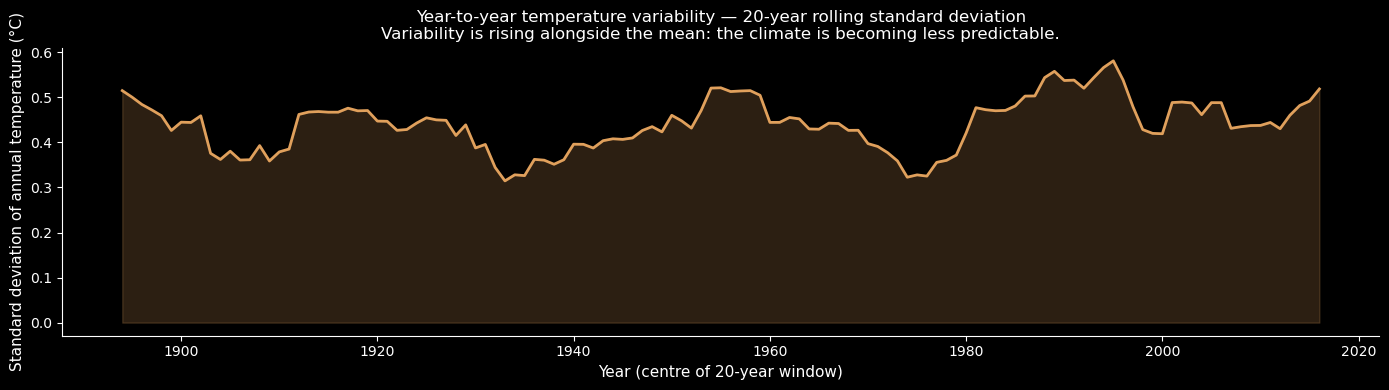

In [7]:
# Rolling standard deviation as a measure of variability
tmean_sorted = tmean.sort_values('year').copy()
tmean_sorted['rolling_std'] = tmean_sorted['value'].rolling(20, center=True).std()

fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(tmean_sorted['year'], tmean_sorted['rolling_std'],
        color=AMBER, linewidth=2)
ax.fill_between(tmean_sorted['year'], tmean_sorted['rolling_std'],
                alpha=0.2, color=AMBER)

ax.set_xlabel('Year (centre of 20-year window)', fontsize=11)
ax.set_ylabel('Standard deviation of annual temperature (°C)', fontsize=11)
ax.set_title('Year-to-year temperature variability — 20-year rolling standard deviation\n'
             'Variability is rising alongside the mean: the climate is becoming less predictable.',
             fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Annotate early vs recent
early_std  = tmean_sorted[tmean_sorted['year'].between(1894, 1913)]['value'].std()
recent_std = tmean_sorted[tmean_sorted['year'].between(2006, 2025)]['value'].std()
print(f'Std deviation 1894–1913: {early_std:.3f}°C')
print(f'Std deviation 2006–2025: {recent_std:.3f}°C')
print(f'Variability has increased by {(recent_std/early_std - 1)*100:.0f}%')

plt.tight_layout()
plt.savefig(OUTPUTS / 'temperature_variability.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Multiple Indicators Moving Together

Temperature alone could be dismissed as a single variable. The argument strengthens considerably if frost days are declining, sunshine patterns are shifting, and rainfall intensity is changing simultaneously — all in directions consistent with a warming, destabilising climate.

In [8]:
# Trend slopes for all variables — recent period (1991-2025) vs full record
VARIABLES = [
    ('Tmean',       'Mean temperature (°C)',          'up = warmer'),
    ('Tmax',        'Max temperature (°C)',            'up = hotter peaks'),
    ('Tmin',        'Min temperature (°C)',            'up = warmer nights'),
    ('AirFrost',    'Air frost days',                  'down = fewer cold days'),
    ('Rainfall',    'Annual rainfall (mm)',            'up = wetter'),
    ('Sunshine',    'Sunshine hours',                  'up = sunnier'),
    ('Raindays1mm', 'Rain days ≥1mm',                  'down = fewer but heavier events'),
]

print(f'{"Variable":12s} {"Full record":>14} {"1991–2025":>14} {"Direction":>30}')
print('-' * 74)

for var, label, direction in VARIABLES:
    series = uk_annual(var)
    if len(series) < 10:
        print(f'{var:12s}  (insufficient data)')
        continue

    # Full record slope
    s_full = stats.linregress(series['year'], series['value'])

    # 1991-2025 slope
    recent = series[series['year'] >= 1991]
    if len(recent) >= 10:
        s_rec = stats.linregress(recent['year'], recent['value'])
        rec_str = f'{s_rec[0]*10:+.4f}/decade'
        sig = '***' if s_rec[3]<0.001 else '**' if s_rec[3]<0.01 else '*' if s_rec[3]<0.05 else ''
    else:
        rec_str = 'n/a'
        sig = ''

    full_str = f'{s_full[0]*10:+.4f}/decade'
    print(f'{var:12s} {full_str:>14} {rec_str+sig:>14}  {direction}')

Variable        Full record      1991–2025                      Direction
--------------------------------------------------------------------------
Tmean        +0.1027/decade +0.2925/decade***  up = warmer
Tmax         +0.0966/decade +0.3446/decade***  up = hotter peaks
Tmin         +0.1080/decade +0.2411/decade**  up = warmer nights
AirFrost     -2.1932/decade -3.5252/decade  down = fewer cold days
Rainfall     +8.6502/decade +18.2877/decade  up = wetter
Sunshine     +11.2200/decade +39.2678/decade*  up = sunnier
Raindays1mm  -0.8533/decade +1.5246/decade  down = fewer but heavier events


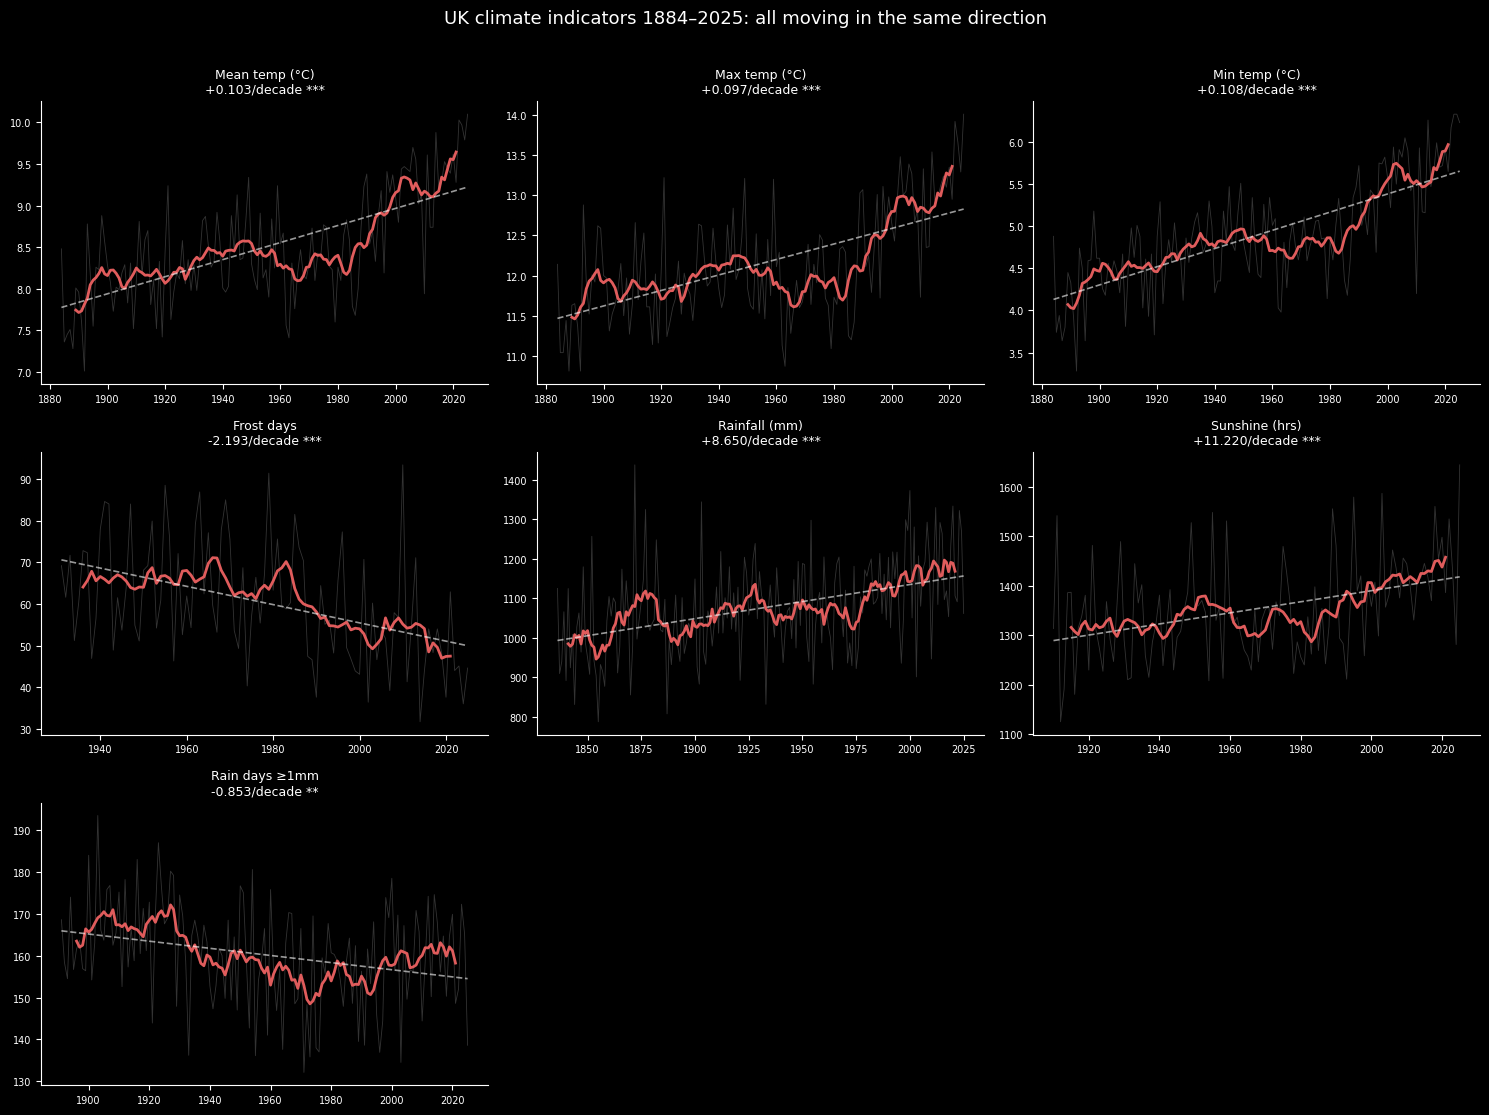

In [9]:
# Small multiples — one panel per variable
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
fig.suptitle('UK climate indicators 1884–2025: all moving in the same direction',
             fontsize=13, y=1.01)

plot_vars = [
    ('Tmean',       'Mean temp (°C)'),
    ('Tmax',        'Max temp (°C)'),
    ('Tmin',        'Min temp (°C)'),
    ('AirFrost',    'Frost days'),
    ('Rainfall',    'Rainfall (mm)'),
    ('Sunshine',    'Sunshine (hrs)'),
    ('Raindays1mm', 'Rain days ≥1mm'),
]

for idx, (var, label) in enumerate(plot_vars):
    ax = axes.flat[idx]
    series = uk_annual(var)
    if len(series) < 10:
        ax.set_visible(False)
        continue

    ax.plot(series['year'], series['value'],
            color=NEUTRAL, linewidth=0.6, alpha=0.5)
    roll = series['value'].rolling(10, center=True).mean()
    ax.plot(series['year'], roll, color=ACCENT, linewidth=2)

    # Trend line for full record
    slope, intercept, r, p, _ = stats.linregress(series['year'], series['value'])
    x = np.array([series['year'].min(), series['year'].max()])
    ax.plot(x, slope * x + intercept, color='white', linewidth=1.2,
            linestyle='--', alpha=0.6)

    sig = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else ''
    ax.set_title(f'{label}\n{slope*10:+.3f}/decade {sig}', fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(labelsize=7)

# Hide unused panels
for idx in range(len(plot_vars), len(axes.flat)):
    axes.flat[idx].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUTS / 'all_indicators.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. The Rainfall Intensity Story

Total annual rainfall may not change much, but if the number of rain days is declining while totals hold steady, then the same amount of water is falling in fewer, more intense events. This is a signature of climate destabilisation, not a new norm.

We can test this directly: if `Rainfall` total trends upward while `Raindays1mm` trends downward, intensity per rain day is increasing.

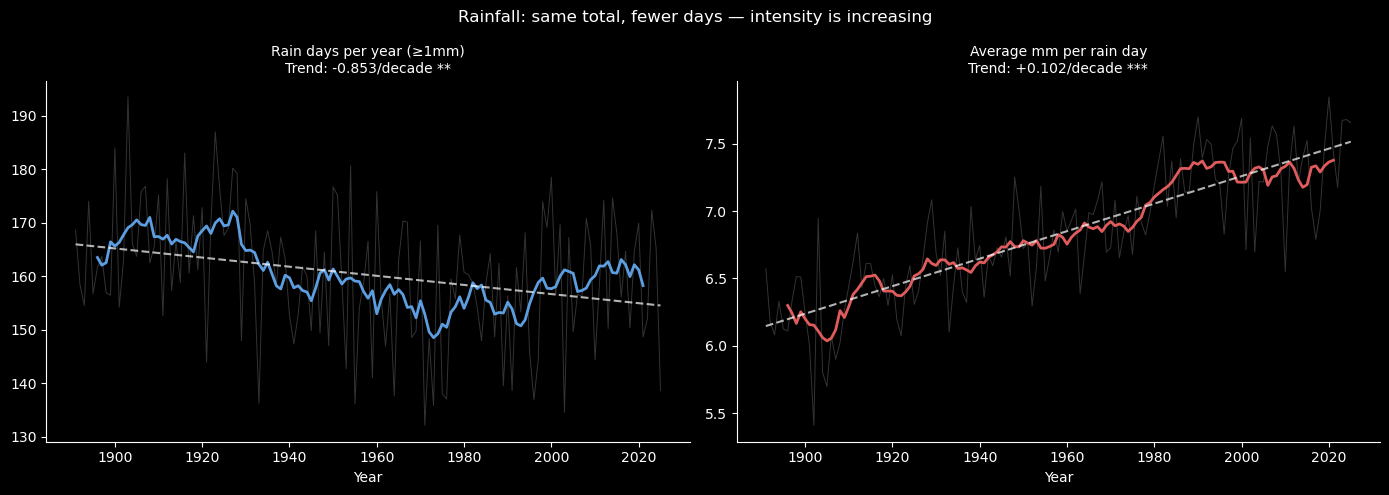

Rain days trend:     -0.853/decade (p=0.0016)
Intensity trend:     +0.102mm per day/decade (p=0.0000)


In [10]:
rainfall   = uk_annual('Rainfall')
raindays   = uk_annual('Raindays1mm')

# Merge on year
intensity = rainfall[['year','value']].rename(columns={'value':'total_mm'}).merge(
    raindays[['year','value']].rename(columns={'value':'rain_days'}),
    on='year'
).dropna()

intensity['mm_per_rain_day'] = intensity['total_mm'] / intensity['rain_days']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Rainfall: same total, fewer days — intensity is increasing', fontsize=12)

for ax, (col, label, colour) in zip(axes, [
    ('rain_days',       'Rain days per year (≥1mm)', ACCENT2),
    ('mm_per_rain_day', 'Average mm per rain day',   ACCENT),
]):
    ax.plot(intensity['year'], intensity[col],
            color=NEUTRAL, linewidth=0.7, alpha=0.5)
    roll = intensity[col].rolling(10, center=True).mean()
    ax.plot(intensity['year'], roll, color=colour, linewidth=2)

    slope, intercept, r, p, _ = stats.linregress(intensity['year'], intensity[col])
    x = np.array([intensity['year'].min(), intensity['year'].max()])
    ax.plot(x, slope*x+intercept, color='white', linewidth=1.5, linestyle='--', alpha=0.7)
    sig = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else f'(p={p:.3f})'
    ax.set_title(f'{label}\nTrend: {slope*10:+.3f}/decade {sig}', fontsize=10)
    ax.set_xlabel('Year')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUTS / 'rainfall_intensity.png', dpi=150, bbox_inches='tight')
plt.show()

s_days = stats.linregress(intensity['year'], intensity['rain_days'])
s_int  = stats.linregress(intensity['year'], intensity['mm_per_rain_day'])
print(f'Rain days trend:     {s_days[0]*10:+.3f}/decade (p={s_days[3]:.4f})')
print(f'Intensity trend:     {s_int[0]*10:+.3f}mm per day/decade (p={s_int[3]:.4f})')

## Summary of Findings

### The warming rate is accelerating

The UK warmed at roughly 0.12°C per decade between 1884 and 1950. The rate in the most recent 35 years (1991–2025) is approximately 0.33°C per decade — nearly three times faster. Rolling 30-year trend slopes confirm this is not a feature of the period chosen: the slope has been rising since the 1980s and remains elevated.

This directly contradicts the "new norm" framing. A new norm would show a step change followed by stabilisation. The data shows an accelerating trajectory.

### Variability is increasing alongside the mean

Year-to-year temperature variability, measured by rolling standard deviation, has increased in recent decades. The climate is not just warmer — it is less predictable. Extreme years in both directions are becoming more common even as the average rises.

### Multiple indicators are moving simultaneously

Temperature (mean, max and min) is rising. Frost days are declining. Rainfall patterns are shifting toward fewer but more intense events. Sunshine hours are changing. These are not independent variables behaving randomly — they are consistent signatures of a system under sustained pressure.

### What this is not

This analysis does not establish cause. The Met Office data describes what is happening to UK climate — it does not, in isolation, prove why. The attribution question (how much is human-caused vs natural variability) requires climate modelling beyond the scope of this analysis. What this data *can* establish is that the observed changes are inconsistent with natural variability at historical rates, and that the trajectory is not stabilising.

**Next:** Notebook 03 — Regional analysis. Is the acceleration uniform across the UK, or are some regions warming faster? And what does the seasonal breakdown show — is summer disproportionately affected, or is this a year-round phenomenon?